In [ ]:
import sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_scores  = "diagnoses_tests.csv"
from google.colab import files
print("⬆️ Upload your data_files.csv")
uploaded = files.upload()

⬆️ Upload your data_files.csv


Saving diagnoses_tests.csv to diagnoses_tests (4).csv


In [ ]:
import pandas as pd
df = pd.read_csv('diagnoses_tests.csv')
X = df.drop(['Diagnoses', 'OASISID'] ,axis=1)
y = df['Diagnoses']

    PSY019  PSY021  ANIMALS   VEG  mentcont  asscmem  srtfree  srttotal  \
0     22.0    33.0       23  17.0       7.0     19.0     34.0      48.0   
1     26.0    32.0       19  14.0       6.0     16.5     27.0      48.0   
2      NaN     NaN       23   NaN       NaN      NaN     29.0      48.0   
3      NaN     NaN       16   NaN       NaN      NaN     34.0      48.0   
4      NaN     NaN       21   NaN       NaN      NaN     35.0      48.0   
5     25.0    42.0       23  15.0       9.0     14.5     28.0      48.0   
6      NaN     NaN       23   NaN       NaN      NaN     31.0      48.0   
7      NaN     NaN       22   NaN       NaN      NaN     38.0      48.0   
8     21.0    22.0       15  16.0       5.0      8.0     29.0      48.0   
9     16.0    20.0       19  13.0       9.0     17.5     30.0      48.0   
10     9.0    22.0       11   6.0       4.0      8.0     11.0      43.0   
11     7.0    16.0        5   3.0       8.0      6.0      NaN       NaN   
12    23.0    43.0       

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=100)

NameError: name 'X' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

imputer = SimpleImputer(strategy='mean')
log_reg = LogisticRegression(penalty= None)
pipeline = Pipeline([('imputer', imputer),('log_reg', log_reg)])
#drop missing
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test[X_train.columns]

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print('Train score:', train_score)
print('Test score:', test_score)

Train score: 1.0
Test score: 0.625


For a condensed dataset that uses the same subjects, the model had a perfect training accuracy but a test accuracy of 0.625, indicating overfitting.

In [ ]:
#attempt using a larger subset of the data
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df_full = pd.read_csv('full_oasis_assesments.csv')
# Drop columns where more than 80% of the values are missing
threshold = 0.8
missing_ratio = df_full.isnull().mean()  # Get % of missing values per column
cols_to_drop = missing_ratio[missing_ratio > threshold].index

# Drop them
df_full_reduced = df_full.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns with >80% missing values")
print("Remaining columns:", df_full_reduced.shape[1])

df_full = df_full.dropna(axis=1, how='all')
# Clean columns
df_full_cleaned = df_full.drop(columns=cols_to_drop,errors='ignore')

# Then group by person
df_grouped = df_full_cleaned.groupby('OASISID').mean(numeric_only=True)

# Optional: drop any remaining rows with NaNs or impute
df_grouped_clean = df_grouped.dropna()  # or use imputation instead
print(df_grouped_clean)

Dropped 16 columns with >80% missing values
Remaining columns: 86
          days_to_visit  age at visit     PSY019     PSY021        SIM  \
OASISID                                                                  
OAS30001    2610.533333     72.346000  20.214286  35.571429  25.333333   
OAS30007    2241.769231     77.728462  23.250000  43.666667  31.000000   
OAS30014    2585.666667     77.479167  20.545455  20.909091  26.333333   
OAS30015    2559.500000     72.322143  25.615385  43.615385  31.333333   
OAS30052    2837.250000     66.837500  19.333333  24.500000  27.500000   
...                 ...           ...        ...        ...        ...   
OAS31159    1878.500000     78.378750  19.000000  36.571429  27.000000   
OAS31160    4749.920000     78.257600  25.956522  40.913043  30.000000   
OAS31168    2458.230769     71.950000  24.181818  34.727273  25.000000   
OAS31172    1503.500000     75.071250  23.500000  29.571429  28.000000   
OAS31178    2102.090909     78.016364  19.2727

The final cleaned dataset includes 160 people and 84 rows, this biases the dataset in favor of completeness , alternated is to impute missing values. May compare the two stratedgies.

In [ ]:
complete_oasis_ids = df_grouped_clean.index.tolist()
complete_oasis_ids_df = pd.DataFrame(complete_oasis_ids, columns=['OASISID'])

# Save to CSV
complete_oasis_ids_df.to_csv('complete_oasis_ids.csv', index=False)


In [ ]:
#join diagnoses csv to df_grouped_clean
df_grouped_clean = df_grouped_clean.reset_index()
df_complete = pd.read_csv('oasis_complete_diagnoses.csv')
df_merged = pd.merge(df_grouped_clean, df_complete, on='OASISID', how='inner')
print(df_merged)

     index   OASISID  days_to_visit  age at visit     PSY019     PSY021  \
0        0  OAS30001    2610.533333     72.346000  20.214286  35.571429   
1        1  OAS30007    2241.769231     77.728462  23.250000  43.666667   
2        2  OAS30014    2585.666667     77.479167  20.545455  20.909091   
3        3  OAS30015    2559.500000     72.322143  25.615385  43.615385   
4        4  OAS30052    2837.250000     66.837500  19.333333  24.500000   
..     ...       ...            ...           ...        ...        ...   
155    155  OAS31159    1878.500000     78.378750  19.000000  36.571429   
156    156  OAS31160    4749.920000     78.257600  25.956522  40.913043   
157    157  OAS31168    2458.230769     71.950000  24.181818  34.727273   
158    158  OAS31172    1503.500000     75.071250  23.500000  29.571429   
159    159  OAS31178    2102.090909     78.016364  19.272727  22.200000   

           SIM    ANIMALS        VEG  mentcont  ...  mocaordy  mocaorpl  \
0    25.333333  20.86666

In [ ]:
#split dataset
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
X_comp = df_merged.drop(['Diagnoses', 'OASISID','age at visit','days_to_visit'] ,axis=1)
y_comp = df_merged['Diagnoses']
X_train, X_test, y_train, y_test = train_test_split(X_comp, y_comp, test_size=0.30, random_state=100)

In [ ]:
#train and test set
X_train, X_test, y_train, y_test = train_test_split(X_comp, y_comp, test_size=0.30, random_state=100)

In [ ]:
#train model
log_reg = LogisticRegression(penalty= None, max_iter=200)
log_reg.fit(X_train, y_train)

# Predict and evaluate
y_pred = log_reg.predict(X_test)
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)

print('Train score:', train_score)
print('Test score:', test_score)

Train score: 0.9910714285714286
Test score: 0.5833333333333334


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training accuracy = 0.99, testing = 0.58. Proceed with hyperarameter fine tuning to address overfitting.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
X_train2, X_validate, y_train2, y_validate = train_test_split(X_train, y_train,test_size =0.30 ,random_state =2024)

log_reg_base= LogisticRegression(penalty= None, max_iter=1000)
log_reg_base.fit(X_train2, y_train2)
y_val_base= log_reg_base.predict(X_validate)
y_training_base = log_reg_base.predict(X_train2)
train_score_base = accuracy_score(y_train2,y_training_base)
val_score_base = accuracy_score(y_validate,y_val_base)
print('training accuracy',train_score_base)
print('validation accuracy' , val_score_base)

# must retune for C hyperparameter
grid={'C':[0.125,0.5,1,2,4,8],'penalty':['l2']}
log_ins = LogisticRegression()
gs=GridSearchCV(estimator=log_ins,param_grid=grid,scoring='accuracy',cv=5)
gs.fit(X_train2,y_train2)
C_inp =gs.best_params_["C"]
print(C_inp)
#retrained model
log_reg= LogisticRegression(penalty= 'l2', max_iter=1000,C= C_inp)
log_reg.fit(X_train2, y_train2)
y_val= log_reg.predict(X_validate)
y_training = log_reg.predict(X_train2)
train_score = accuracy_score(y_train2,y_training)
val_score = accuracy_score(y_validate,y_val)
print('training accuracy retrained',train_score)
print('validation accuracy retrained' , val_score)

training accuracy 1.0
validation accuracy 0.7647058823529411


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

2
training accuracy retrained 1.0
validation accuracy retrained 0.7941176470588235


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C= 2 was best hyperparameter, still overfitting since training accuracy = 1, testing accuracy improved to 0.79.

Precison 0.8076923076923077
Recall 0.9130434782608695


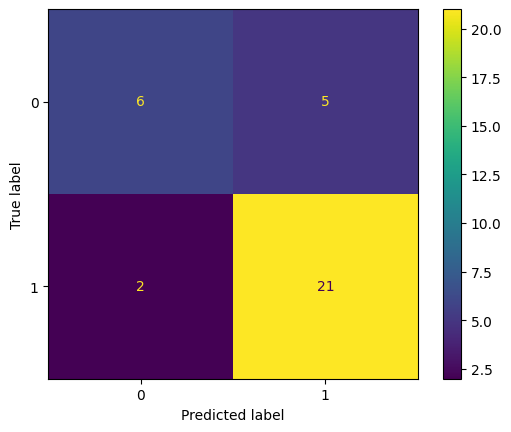

In [ ]:
cm1= confusion_matrix(y_validate, y_val)
cm1_display = ConfusionMatrixDisplay(cm1).plot()
precision1 = precision_score(y_validate,y_val)
recall1 = recall_score(y_validate,y_val)
print('Precison',precision1)
print('Recall',recall1)

The confusion matrix above , based on the adjusted model has a precision of 0.81 and a recall of 0.91. Which to say that of all predicted cognitively normal subjects(true cases), 81% were actually cognitively normal. Of all the true cases (cognitively normal) the model identified 91% of those. The rate of false positives was 5/26 or 19% and the rate of false negatives was 2/8 or 25%. This is likely due to how the diagnoses criteria was decided since; many subjects were inbewteen in terms of status (longitudinal study) and I had to make a definitive classification decison and for each subject each criteria is a mean of all thier visits.

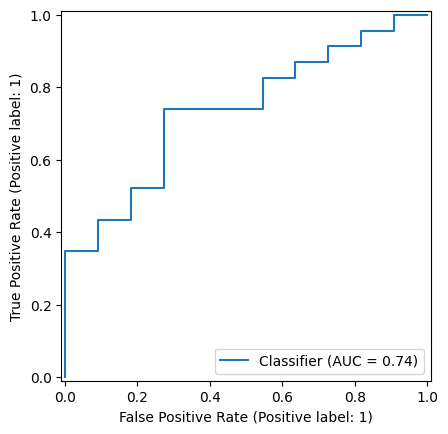

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.svm import SVC
clf = SVC(random_state=0).fit(X_train2, y_train2)
y_pred = clf.decision_function(X_validate)
RocCurveDisplay.from_predictions(y_validate,y_pred)